# REDES NEURAIS

In [13]:
#pip install keras-tuner
#pip install --upgrade keras

In [14]:
# Bibliotecas de manipulação de dados e visualização
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e métricas
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc, precision_score, recall_score, f1_score
#from sklearn.pipeline import Pipeline
#from scikeras.wrappers import KerasClassifier

# Keras (via TensorFlow)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Otimização de hiperparâmetros
from kerastuner.tuners import RandomSearch

# TensorFlow
import tensorflow as tf
tf.config.run_functions_eagerly(True)


In [15]:
base = pd.read_csv('data_balanceado_sem_pre_diabetes.csv')

In [16]:
X = base.drop(['Diabetes_012'], axis=1)
y = base['Diabetes_012'].astype(int).values 
#print(y.shape)
#print(y)

In [17]:
# Histórico das acurácias
historico_accuracy = []
historico_val_accuracy = []

# Vetor com as métricas  de cada subsampling
acuracias = []
precisions = []
recalls = []
f1_scores = []
matrizes_confusao = []

# Curva ROC
fpr_list = []
tpr_list = []
auc_list = []

In [18]:
# K-Fold estratificado
# shuffle=True aleatoriza a ordem das entradas em X
kfold = StratifiedKFold(n_splits=8, shuffle=True, random_state=42)

In [19]:
fold = 1

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=40, min_lr=1e-8)

for train_idx, test_idx in kfold.split(X, y):
    print(f'\n##### FOLD {fold} #####')

    # Separando os dados
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Normalização 
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # One-hot encoding para o Keras (feito aqui, pois a função kfold.slipt não aceita formato dummy)
    y_train_cat = to_categorical(y_train, num_classes=2)
    y_test_cat = to_categorical(y_test, num_classes=2)

    # Modelo (advindo do tuner para hold-out)
    modelo = Sequential()
    modelo.add(Input(shape=(X.shape[1],)))
    modelo.add(Dense(144, activation='relu'))
    modelo.add(Dropout(0.2))
    modelo.add(Dense(104, activation='relu'))
    modelo.add(Dropout(0.2))
    modelo.add(Dense(2, activation='softmax'))

    modelo.compile(optimizer=Adam(learning_rate=1e-5),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

    # Treinamento
    historico = modelo.fit(X_train, y_train_cat,
                           validation_data=(X_test, y_test_cat),
                           epochs=25,
                           callbacks=[early_stop, rlr],
                           verbose=1)

    
    # Predição
    y_pred_probs = modelo.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1) # vetor com rótulos inteiros

    # Guardando métricas
    # O peso (weighted) é dado de acordo com ocorrência da classe
    # Sem divisão por zero
    acuracias.append(accuracy_score(y_test, y_pred))
    precisions.append(precision_score(y_test, y_pred, average='weighted', zero_division=0))
    recalls.append(recall_score(y_test, y_pred, average='weighted', zero_division=0))
    f1_scores.append(f1_score(y_test, y_pred, average='weighted', zero_division=0))
    matrizes_confusao.append(confusion_matrix(y_test, y_pred))

    # Curva ROC
    y_prob = y_pred_probs[:, 1]
    
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    fpr_list.append(fpr)
    tpr_list.append(tpr)
    auc_list.append(roc_auc)

    # Histórico da acurácia
    historico_accuracy.append(historico.history['accuracy'])
    historico_val_accuracy.append(historico.history['val_accuracy'])

    fold += 1



##### FOLD 1 #####
Epoch 1/25


C:\Users\apisa\anaconda3\Lib\site-packages\tensorflow\python\data\ops\structured_function.py:265: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


1161/1161 [==============================] - 52s 45ms/step - loss: 0.6140 - accuracy: 0.6678 - val_loss: 0.5767 - val_accuracy: 0.7152 - lr: 1.0000e-05
Epoch 2/25
1161/1161 [==============================] - 49s 42ms/step - loss: 0.5727 - accuracy: 0.7078 - val_loss: 0.5545 - val_accuracy: 0.7192 - lr: 1.0000e-05
Epoch 3/25
1161/1161 [==============================] - 49s 42ms/step - loss: 0.5584 - accuracy: 0.7149 - val_loss: 0.5473 - val_accuracy: 0.7231 - lr: 1.0000e-05
Epoch 4/25
1161/1161 [==============================] - 49s 42ms/step - loss: 0.5525 - accuracy: 0.7191 - val_loss: 0.5446 - val_accuracy: 0.7231 - lr: 1.0000e-05
Epoch 5/25
1161/1161 [==============================] - 52s 44ms/step - loss: 0.5498 - accuracy: 0.7227 - val_loss: 0.5435 - val_accuracy: 0.7250 - lr: 1.0000e-05
Epoch 6/25
1161/1161 [==============================] - 45s 39ms/step - loss: 0.5487 - accuracy: 0.7235 - val_loss: 0.5428 - val_accuracy: 0.7248 - lr: 1.0000e-05
Epoch 7/25
1161/1161 [===========

C:\Users\apisa\anaconda3\Lib\site-packages\tensorflow\python\data\ops\structured_function.py:265: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


1161/1161 [==============================] - 58s 50ms/step - loss: 0.6344 - accuracy: 0.6477 - val_loss: 0.5889 - val_accuracy: 0.7118 - lr: 1.0000e-05
Epoch 2/25
1161/1161 [==============================] - 67s 58ms/step - loss: 0.5776 - accuracy: 0.7100 - val_loss: 0.5581 - val_accuracy: 0.7177 - lr: 1.0000e-05
Epoch 3/25
1161/1161 [==============================] - 67s 58ms/step - loss: 0.5588 - accuracy: 0.7177 - val_loss: 0.5483 - val_accuracy: 0.7190 - lr: 1.0000e-05
Epoch 4/25
1161/1161 [==============================] - 60s 52ms/step - loss: 0.5537 - accuracy: 0.7197 - val_loss: 0.5448 - val_accuracy: 0.7211 - lr: 1.0000e-05
Epoch 5/25
1161/1161 [==============================] - 63s 55ms/step - loss: 0.5500 - accuracy: 0.7211 - val_loss: 0.5432 - val_accuracy: 0.7224 - lr: 1.0000e-05
Epoch 6/25
1161/1161 [==============================] - 65s 56ms/step - loss: 0.5494 - accuracy: 0.7244 - val_loss: 0.5421 - val_accuracy: 0.7239 - lr: 1.0000e-05
Epoch 7/25
1161/1161 [===========

...

1161/1161 [==============================] - 47s 41ms/step - loss: 0.6666 - accuracy: 0.5873 - val_loss: 0.6092 - val_accuracy: 0.7054 - lr: 1.0000e-05
Epoch 2/25
1161/1161 [==============================] - 45s 39ms/step - loss: 0.5922 - accuracy: 0.6994 - val_loss: 0.5637 - val_accuracy: 0.7245 - lr: 1.0000e-05
Epoch 3/25
1161/1161 [==============================] - 45s 39ms/step - loss: 0.5636 - accuracy: 0.7154 - val_loss: 0.5496 - val_accuracy: 0.7262 - lr: 1.0000e-05
Epoch 4/25
1161/1161 [==============================] - 49s 42ms/step - loss: 0.5531 - accuracy: 0.7226 - val_loss: 0.5457 - val_accuracy: 0.7296 - lr: 1.0000e-05
Epoch 5/25
1161/1161 [==============================] - 48s 41ms/step - loss: 0.5506 - accuracy: 0.7221 - val_loss: 0.5446 - val_accuracy: 0.7305 - lr: 1.0000e-05
Epoch 6/25
1161/1161 [==============================] - 46s 40ms/step - loss: 0.5484 - accuracy: 0.7217 - val_loss: 0.5442 - val_accuracy: 0.7303 - lr: 1.0000e-05
Epoch 7/25
1161/1161 [===========

C:\Users\apisa\anaconda3\Lib\site-packages\tensorflow\python\data\ops\structured_function.py:265: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


Epoch 1/25
1161/1161 [==============================] - 104s 89ms/step - loss: 0.6617 - accuracy: 0.6010 - val_loss: 0.5993 - val_accuracy: 0.7103 - lr: 1.0000e-05
Epoch 2/25
1161/1161 [==============================] - 92s 79ms/step - loss: 0.5937 - accuracy: 0.6951 - val_loss: 0.5535 - val_accuracy: 0.7280 - lr: 1.0000e-05
Epoch 3/25
1161/1161 [==============================] - 102s 88ms/step - loss: 0.5669 - accuracy: 0.7111 - val_loss: 0.5372 - val_accuracy: 0.7309 - lr: 1.0000e-05
Epoch 4/25
1161/1161 [==============================] - 100s 86ms/step - loss: 0.5590 - accuracy: 0.7144 - val_loss: 0.5314 - val_accuracy: 0.7341 - lr: 1.0000e-05
Epoch 5/25
1161/1161 [==============================] - 103s 89ms/step - loss: 0.5549 - accuracy: 0.7175 - val_loss: 0.5286 - val_accuracy: 0.7361 - lr: 1.0000e-05
Epoch 6/25
1161/1161 [==============================] - 89s 77ms/step - loss: 0.5525 - accuracy: 0.7190 - val_loss: 0.5272 - val_accuracy: 0.7378 - lr: 1.0000e-05
Epoch 7/25
1161/11

C:\Users\apisa\anaconda3\Lib\site-packages\tensorflow\python\data\ops\structured_function.py:265: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


1161/1161 [==============================] - 101s 87ms/step - loss: 0.6251 - accuracy: 0.6616 - val_loss: 0.5828 - val_accuracy: 0.7071 - lr: 1.0000e-05
Epoch 2/25
1161/1161 [==============================] - 100s 86ms/step - loss: 0.5750 - accuracy: 0.7079 - val_loss: 0.5573 - val_accuracy: 0.7160 - lr: 1.0000e-05
Epoch 3/25
1161/1161 [==============================] - 97s 84ms/step - loss: 0.5577 - accuracy: 0.7173 - val_loss: 0.5491 - val_accuracy: 0.7164 - lr: 1.0000e-05
Epoch 4/25
1161/1161 [==============================] - 104s 90ms/step - loss: 0.5528 - accuracy: 0.7222 - val_loss: 0.5460 - val_accuracy: 0.7207 - lr: 1.0000e-05
Epoch 5/25
1161/1161 [==============================] - 101s 87ms/step - loss: 0.5508 - accuracy: 0.7229 - val_loss: 0.5444 - val_accuracy: 0.7231 - lr: 1.0000e-05
Epoch 6/25
1161/1161 [==============================] - 89s 76ms/step - loss: 0.5488 - accuracy: 0.7240 - val_loss: 0.5433 - val_accuracy: 0.7258 - lr: 1.0000e-05
Epoch 7/25
1161/1161 [=======

### MÉTRICAS

In [20]:
# Métricas médias e desvios padrão
media_acuracia = np.mean(acuracias)
desvio_acuracia = np.std(acuracias)

media_precision = np.mean(precisions)
desvio_precision = np.std(precisions)

media_recall = np.mean(recalls)
desvio_recall = np.std(recalls)

media_f1 = np.mean(f1_scores)
desvio_f1 = np.std(f1_scores)

print(f"Acurácia média: {media_acuracia:.4f} ± {desvio_acuracia:.4f}")
print(f"Precisão média: {media_precision:.4f} ± {desvio_precision:.4f}")
print(f"Recall média: {media_recall:.4f} ± {desvio_recall:.4f}")
print(f"F1-score médio: {media_f1:.4f} ± {desvio_f1:.4f}")

Acurácia média: 0.7315 ± 0.0065
Precisão média: 0.7340 ± 0.0062
Recall média: 0.7315 ± 0.0065
F1-score médio: 0.7308 ± 0.0066


In [21]:
##### Para verificar o histórico de acurácias

# Toma-se o menor num de épocas possíveis de dentre os objetos em historico_accuracy (early stop)
min_epocas = min(len(h) for h in historico_accuracy)

# Truncando todos os históricos para o mesmo número de épocas
historico_accuracy = [h[:min_epocas] for h in historico_accuracy]
historico_val_accuracy = [h[:min_epocas] for h in historico_val_accuracy]

# Converter para numpy arrays
acc_array = np.array(historico_accuracy)        # shape: (folds, epochs)
val_acc_array = np.array(historico_val_accuracy)

# Média e desvio por época
acc_mean = acc_array.mean(axis=0)
acc_std = acc_array.std(axis=0)
val_acc_mean = val_acc_array.mean(axis=0)
val_acc_std = val_acc_array.std(axis=0)


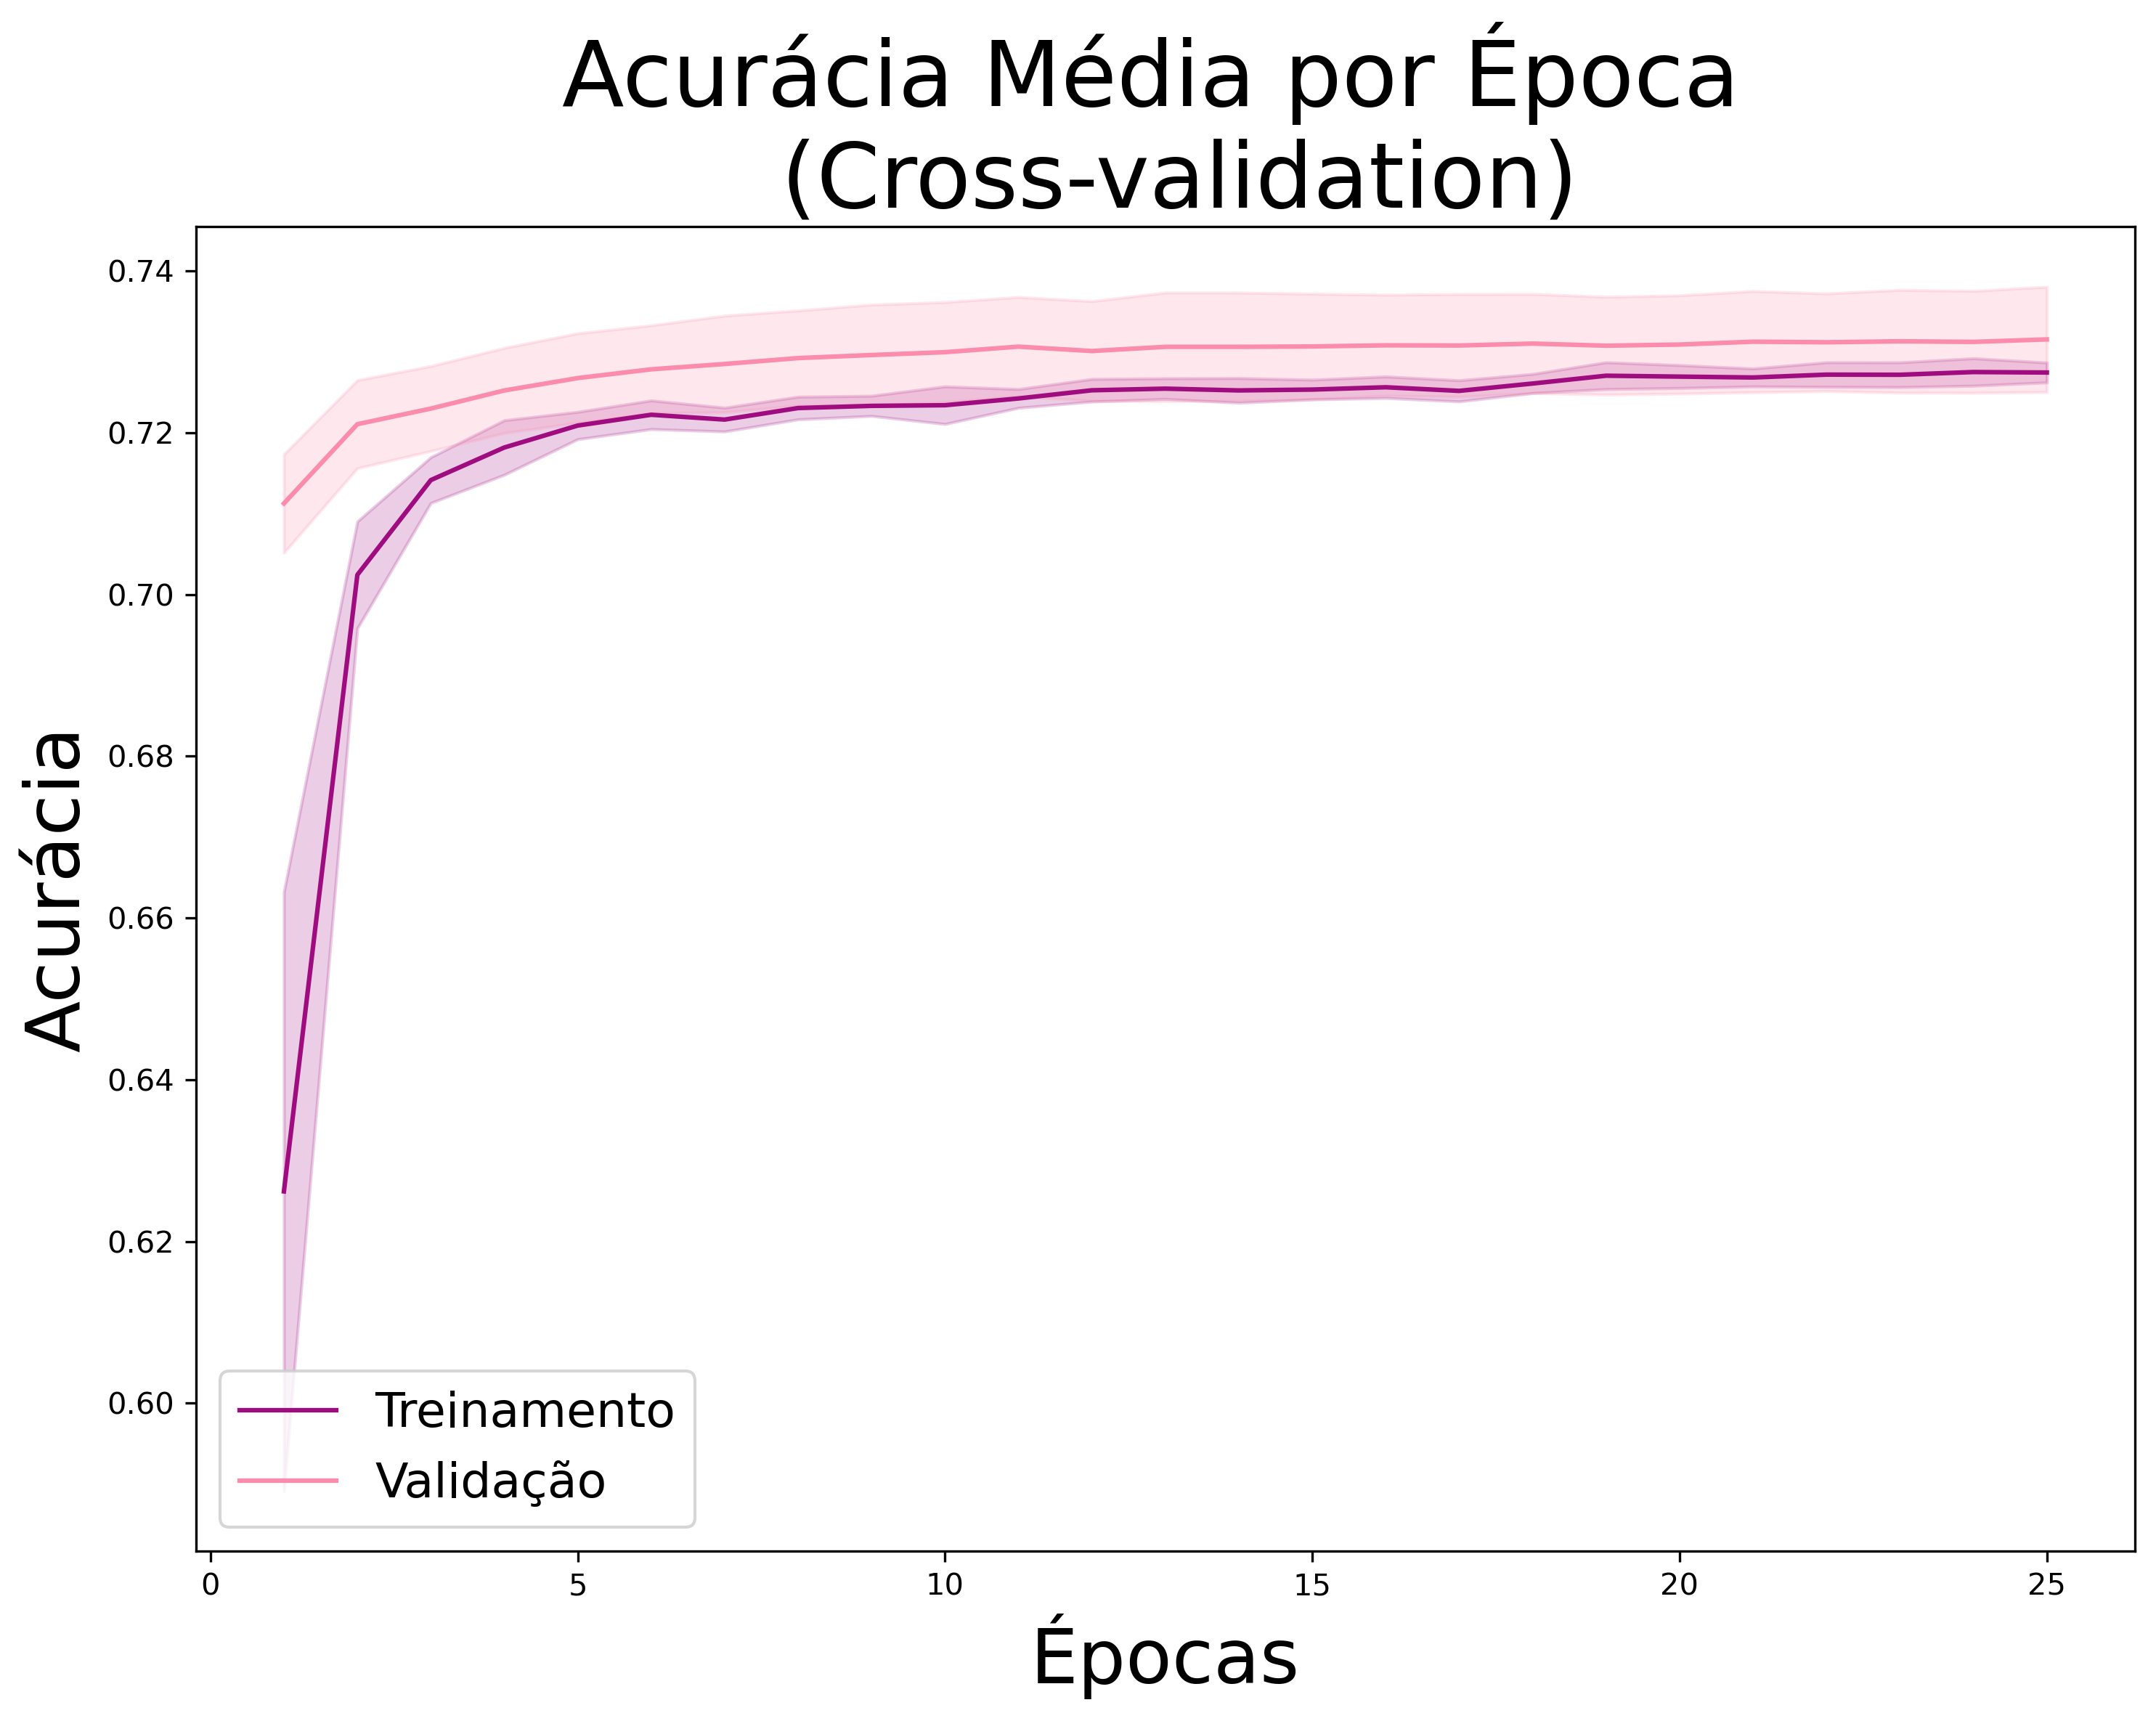

In [22]:
# Visualizar o desempenho durante o treinamento
plt.figure(figsize=(10, 8), dpi=300)

epocas = range(1, min_epocas + 1)

# Curva de treino
plt.plot(epocas, acc_mean, label='Treinamento', color='#9f0c7f')
plt.fill_between(epocas, acc_mean - acc_std, acc_mean + acc_std, alpha=0.2, color='#9f0c7f')

# Curva de validação
plt.plot(epocas, val_acc_mean, label='Validação', color='#fb8cac')
plt.fill_between(epocas, val_acc_mean - val_acc_std, val_acc_mean + val_acc_std, alpha=0.2, color='#fb8cac')

plt.xlabel('Épocas', fontsize=25)
plt.ylabel('Acurácia', fontsize=25)
plt.title('Acurácia Média por Época \n (Cross-validation)', fontsize=30)
plt.legend(fontsize=16)
plt.tight_layout()
plt.savefig('desempenho_rede_neural_crossval.png', dpi=300)
plt.show()


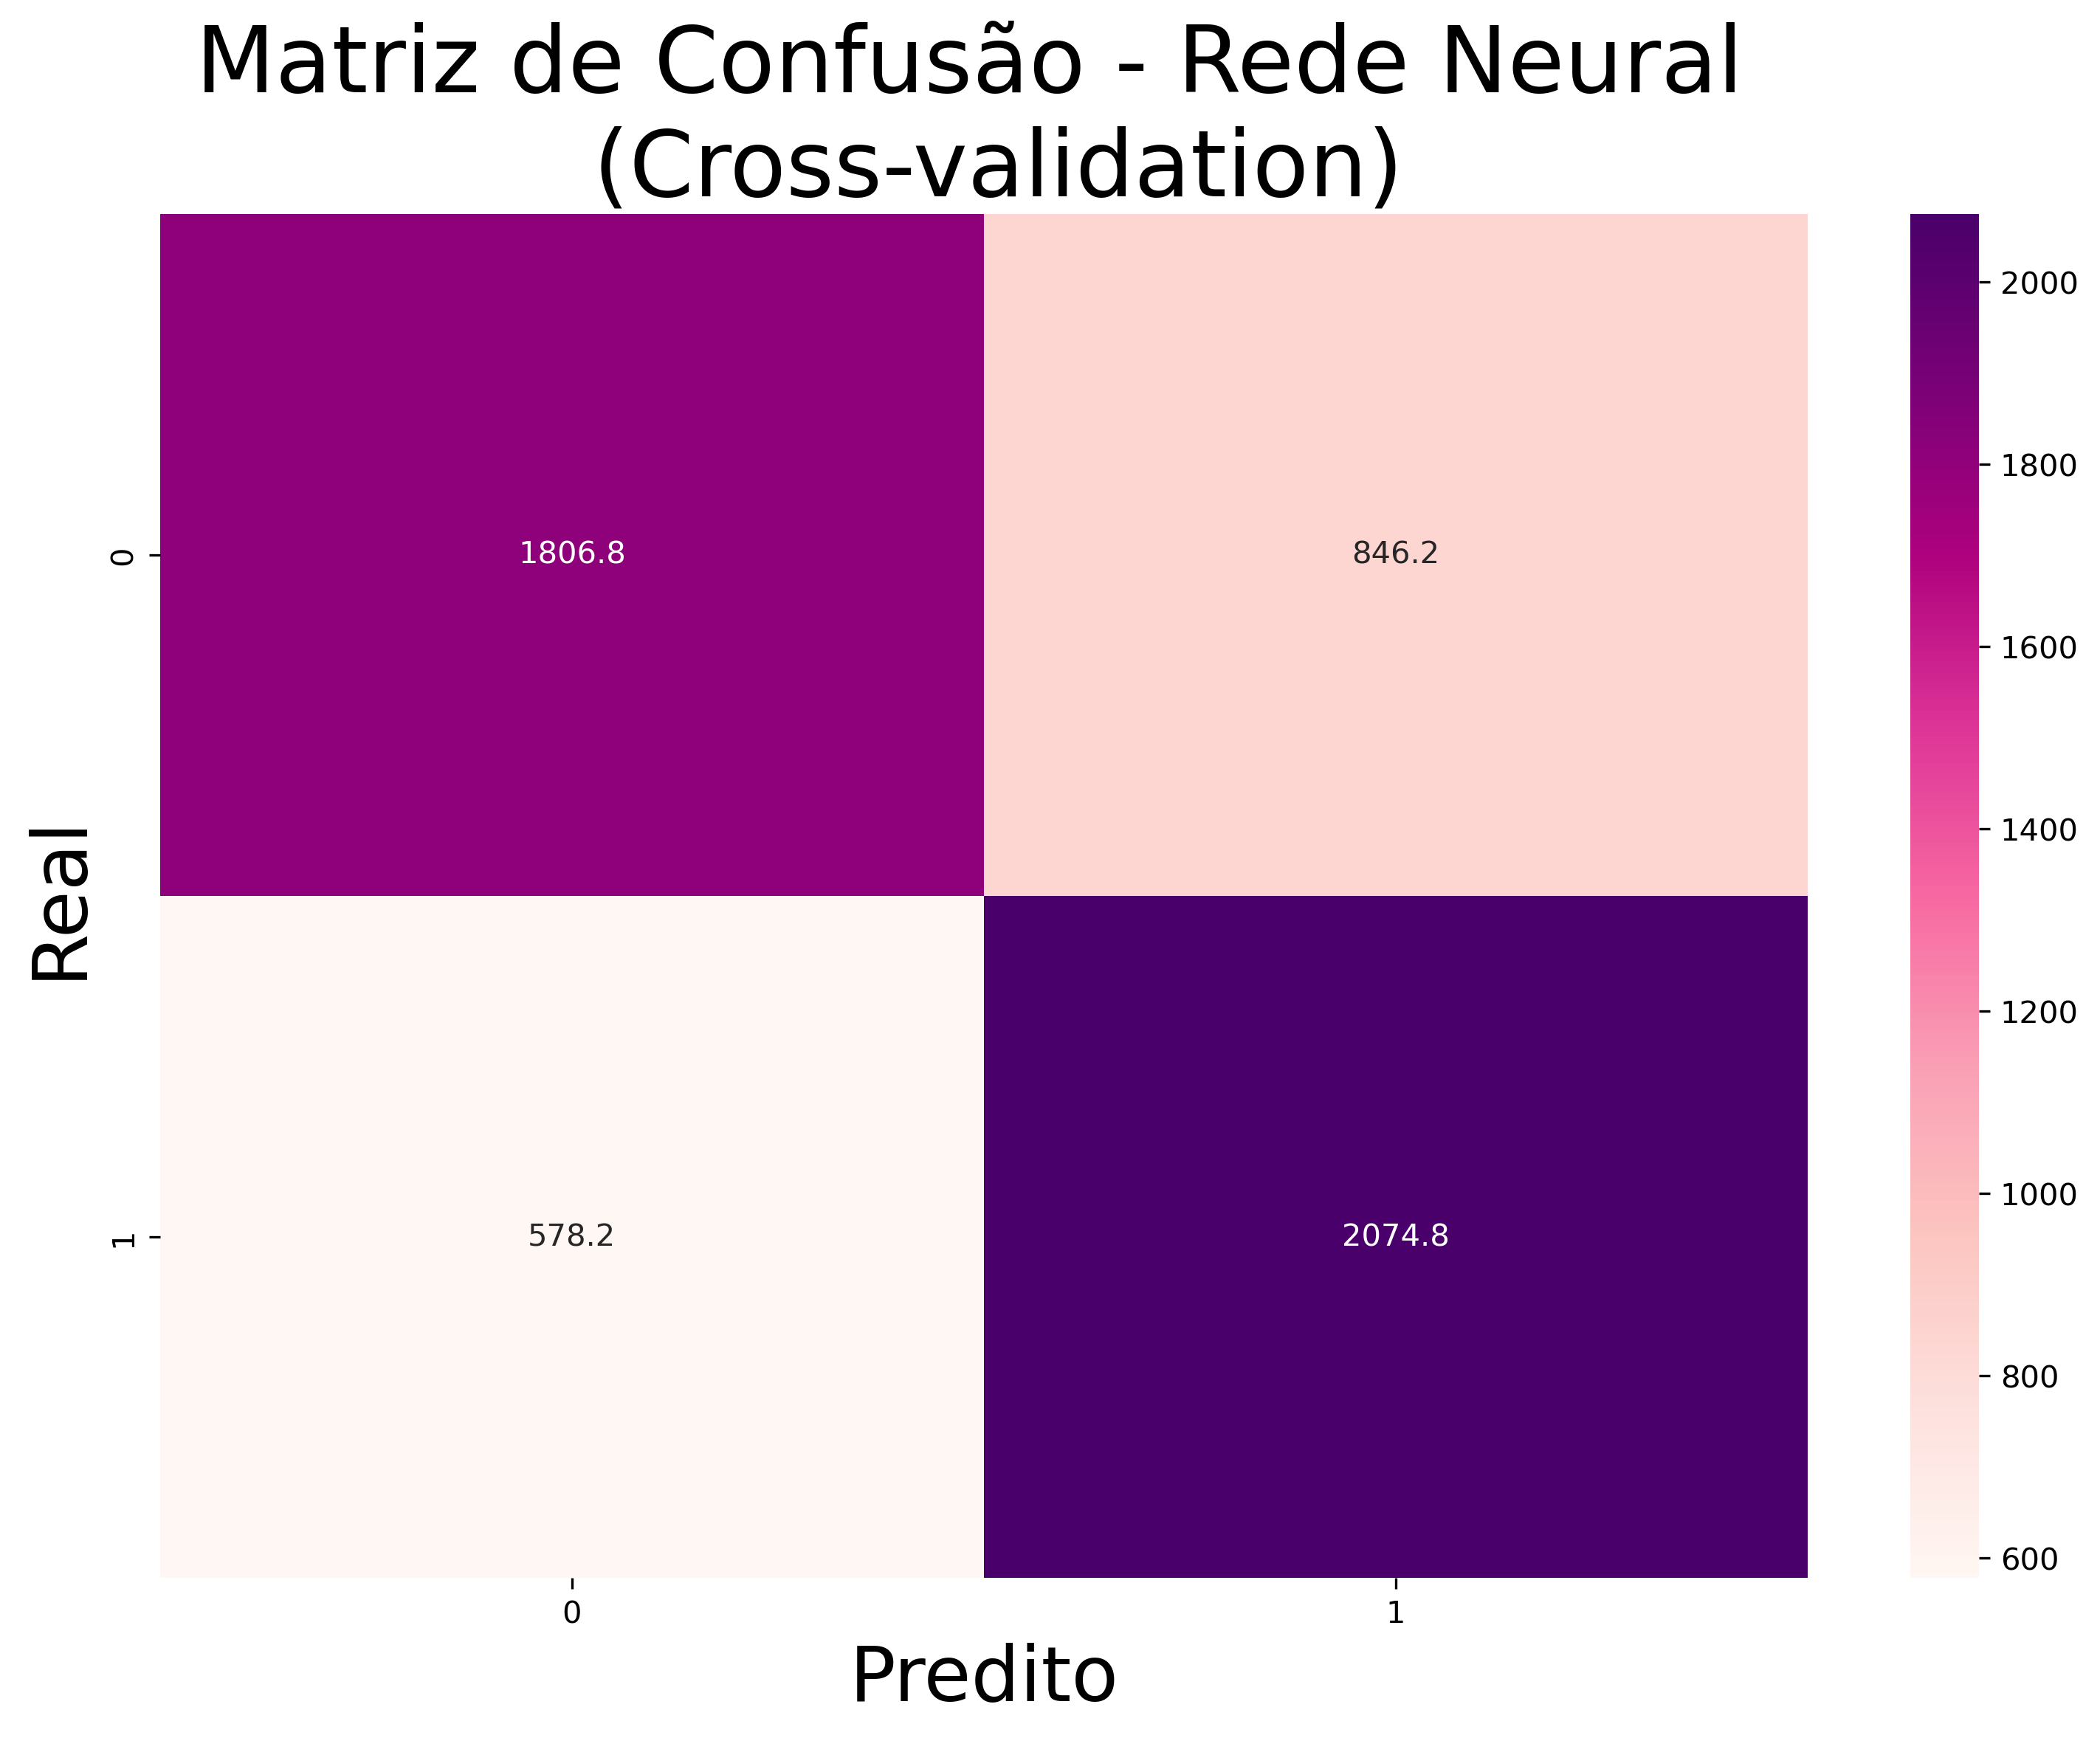

In [23]:
#matriz de confusão
media_matriz = np.mean(matrizes_confusao, axis=0)

plt.figure(figsize=(12, 8), dpi=300)
sns.heatmap(media_matriz, annot=True, fmt=".1f", cmap="RdPu")
plt.xlabel("Predito",fontsize=25)
plt.ylabel("Real",fontsize =25)
plt.title("Matriz de Confusão - Rede Neural \n (Cross-validation)", fontsize=30)
plt.savefig("matriz_confusao_rede_neural_crossval.png", dpi=300)

### CURVA ROC

C:\Users\apisa\AppData\Local\Temp\ipykernel_3096\4024173256.py:15: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], "k--", lw=2, color='#a80dbd')


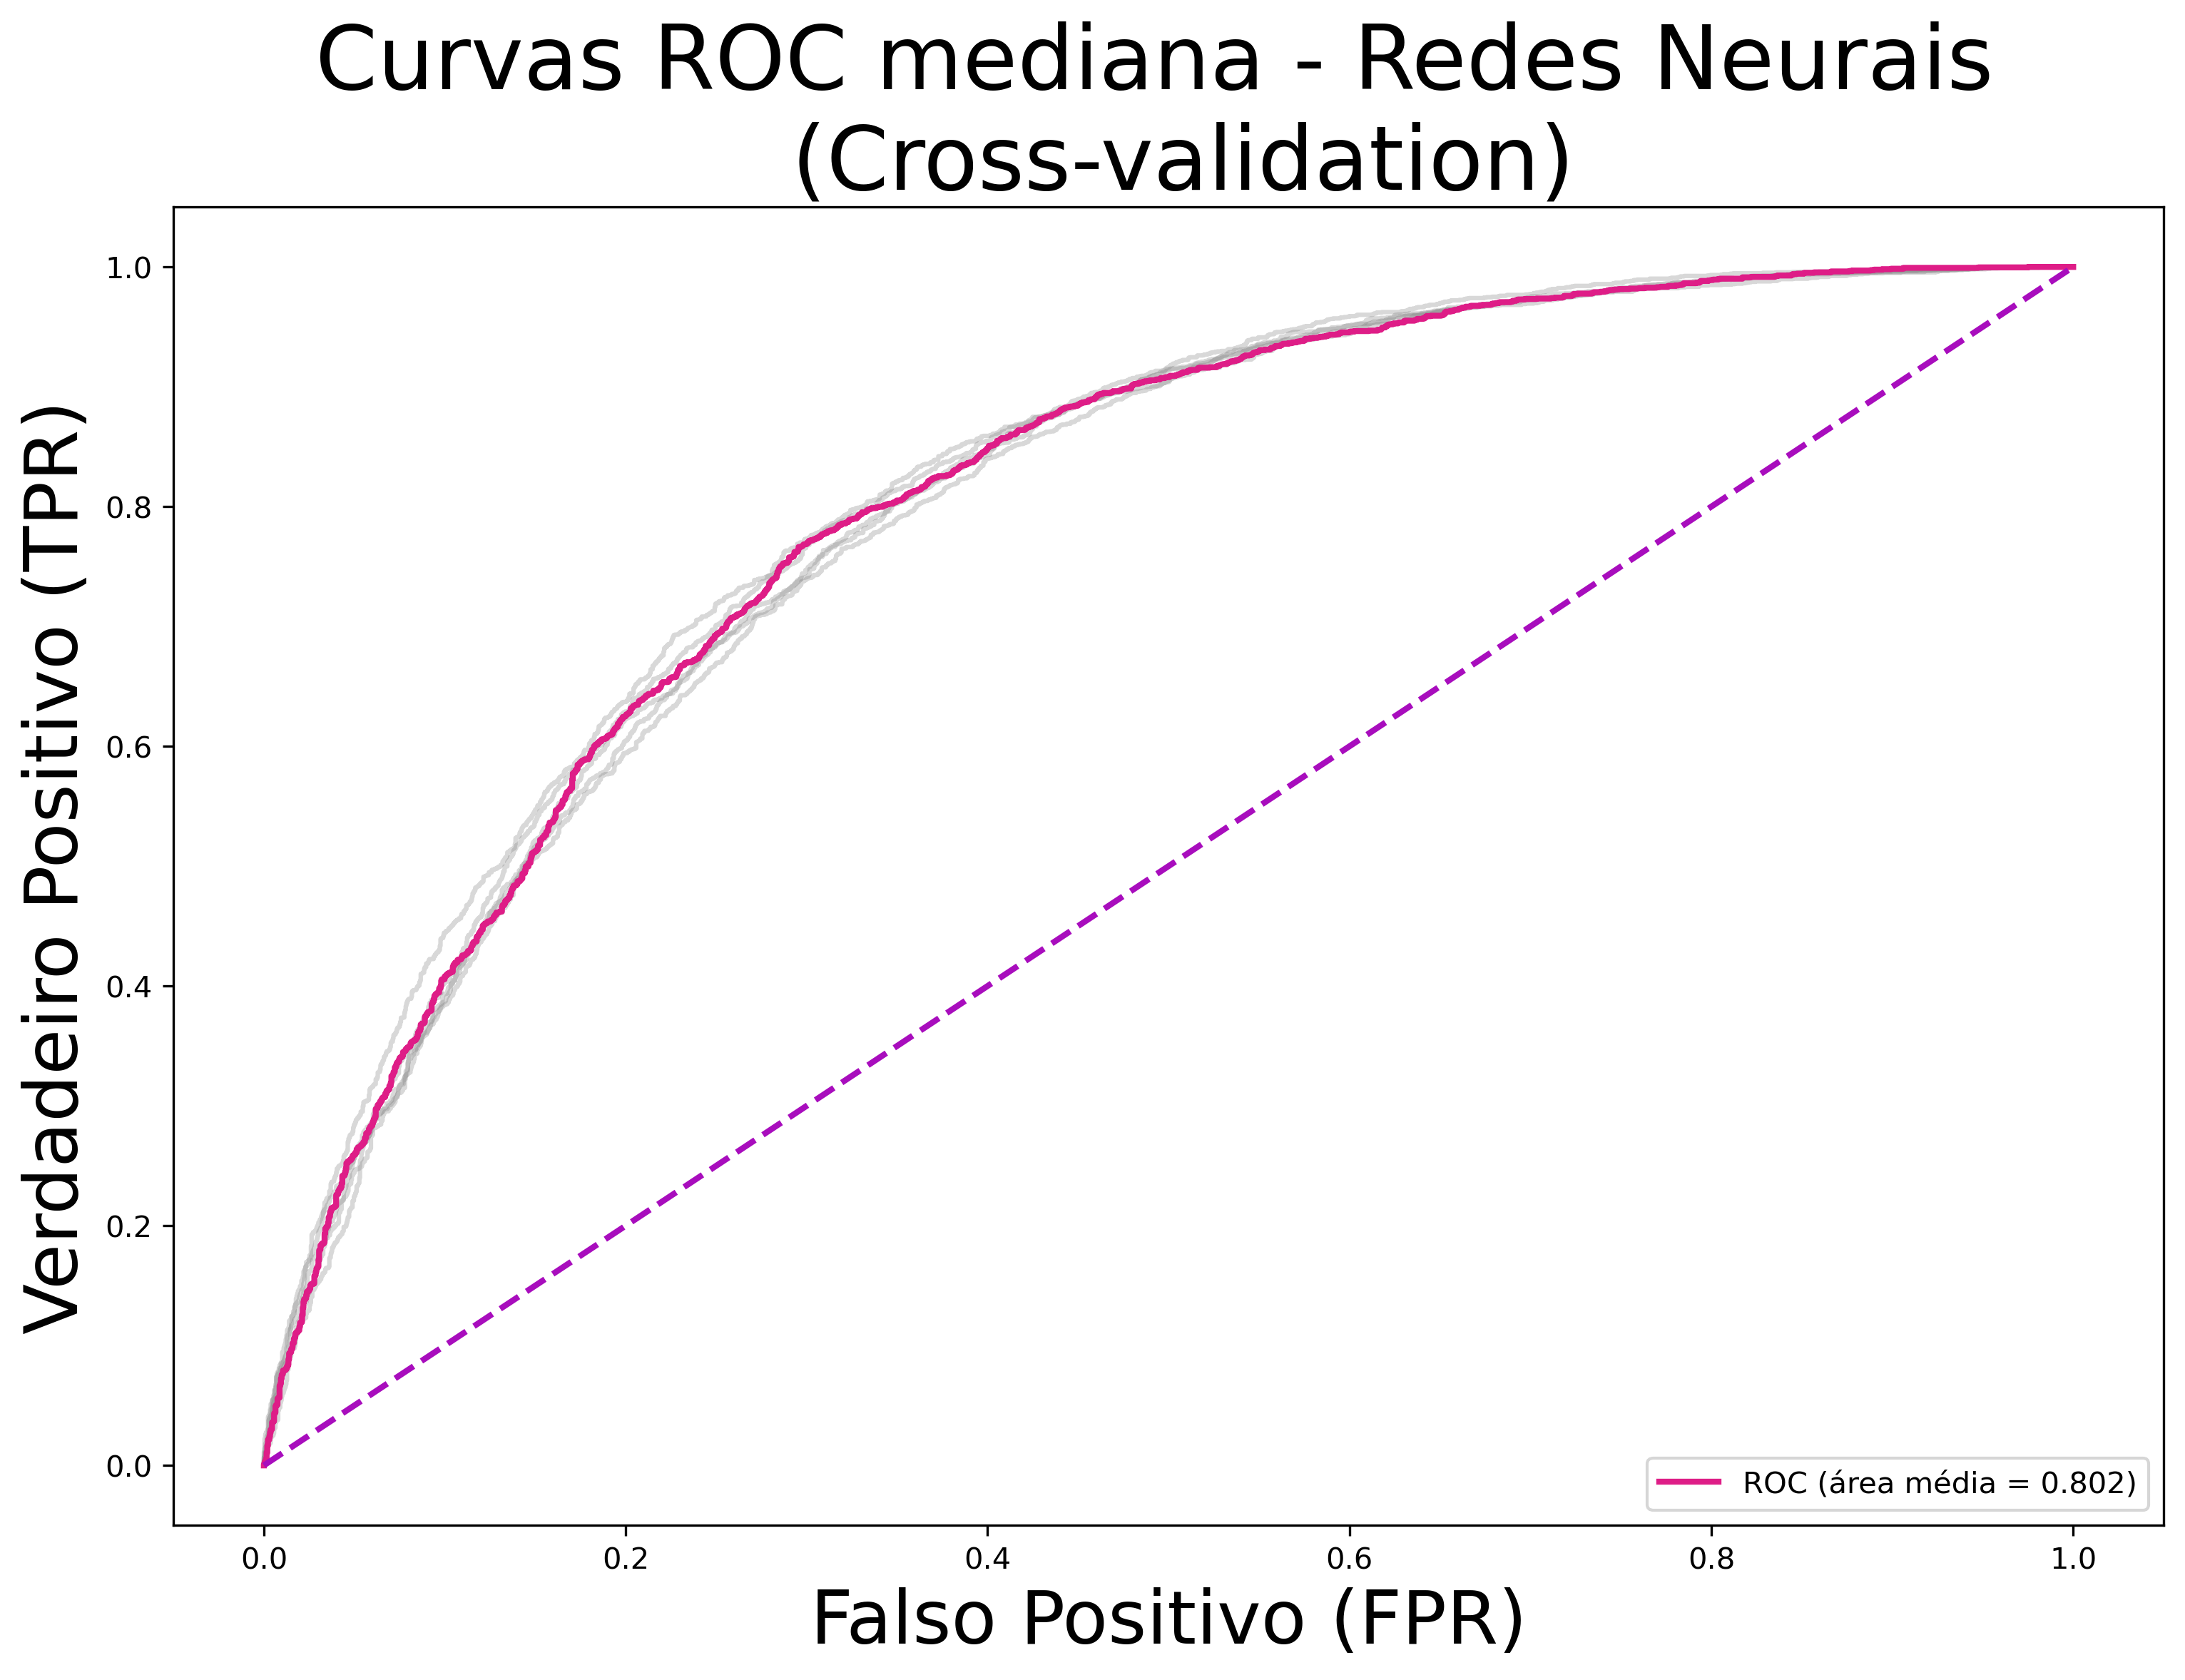

In [24]:
# Plotando
plt.figure(figsize=(12, 8),dpi=300)

# Curvas individuais
for i in range(5):
    plt.plot(fpr_list[i], tpr_list[i], color="gray", alpha=0.3)

# Curva média aproximada
# AUC mediana
idx_mediana = np.argsort(auc_list)[len(auc_list)//2]
plt.plot(fpr_list[idx_mediana], tpr_list[idx_mediana],
         color='#de1d87', lw=2, label=f"ROC (área média = {np.mean(auc_list):.3f})")

# Linha aleatória
plt.plot([0, 1], [0, 1], "k--", lw=2, color='#a80dbd')

plt.xlabel("Falso Positivo (FPR)", fontsize=25)
plt.ylabel("Verdadeiro Positivo (TPR)", fontsize=25)
plt.title("Curvas ROC mediana - Redes Neurais \n (Cross-validation)", fontsize=30)
plt.legend(loc="lower right")
plt.savefig("redes_neurais_curva_roc_crossval.png", dpi=300)